# **--- GETAROUND PROJECT (pricing optimization : MODEL TRAINING AND SELECTION) ---** #

### **Project context and approach**

Getaround is a car-sharing platform where car owners rent their vehicles.
The objective of this project is to build a machine learning model that predicts the optimal rental price for a vehicle based on its characteristics.

This notebook focuses on the model training and selection phase.

Pipeline:
1. Data preprocessing
2. Feature engineering
3. Model training
4. Hyperparameter tuning
5. Model comparison
6. Model registration with 

Our goal here is to predict a continuous numerical value (the rental price) so we will try different regression models and hyperparameter optimizations:
1. Linear Regression (as a baseline)
2. Random Forest Regressor
3. XGBoost Regressor

Each model and its metrics will be logged into MLflow and we will evaluate the models using the following metrics:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R-squared (R2)
These metrics allow us to evaluate both prediction accuracy and error magnitude. The dataset is split into training and testing sets to evaluate model generalization.

The model with the best performance will be assigned the "Production" alias in MLflow Model Registry. This model will then be used for making predictions in our API.

### **1. Importing Required Libraries**

In [77]:
import numpy as np
import pandas as pd

import mlflow
import mlflow.sklearn

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

### **2. Loading the Preprocessed Datasets**

In [78]:
X_train = np.load('../DATA/Data_processed/X_train_preprocessed.npy', allow_pickle=True)
X_test = np.load('../DATA/Data_processed/X_test_preprocessed.npy', allow_pickle=True)
y_train = np.load('../DATA/Data_processed/y_train.npy', allow_pickle=True)
y_test = np.load('../DATA/Data_processed/y_test.npy', allow_pickle=True)

### **3. Setting up MLflow Tracking**

In [80]:
mlflow.set_tracking_uri("http://localhost:5050")
mlflow.set_experiment("Rental_Price_Prediction")

<Experiment: artifact_location=('/Users/charlescabral/Desktop/Mounia/FORMATION JEDHA/1. '
 'JEDHA_FULLSTACK/0.PROJECTS_CERTIF/N°8_Getaround '
 'projects/N°2_Getaround_pricing/mlruns/1'), creation_time=1775313323873, experiment_id='1', last_update_time=1775313323873, lifecycle_stage='active', name='Rental_Price_Prediction', tags={}>

### **4. Training and Evaluating Models**

In this chapter, we will train and evaluate different regression models to predict rental prices. Our goal is to find the best performing model by following these key steps:
1. Train various models on the training set
2. Evaluate each model's performance on the test set
3. Log models, parameters, and metrics in MLflow for comparison and reproducibility

We will test the following models:
- Linear Regression (baseline)
- Ridge Regression (linear model with regularization)  
- Random Forest Regressor
- XGBoost Regressor

All models use the preprocessed and standardized features from the preprocessing notebook.

For each model, we will:
1. Start an MLflow run
2. Train the model
3. Evaluate the model on the test set
4. Log the model and its parameters in MLflow
5. Log the evaluation metrics in MLflow

To do so, let's first create a function train_and_log_model.

In [81]:
# Function to train a model and log it with its metrics into MLflow

def train_and_log_model(model, model_name, X_train, y_train, X_test, y_test, params=None, search_type='grid'):
    with mlflow.start_run(run_name=model_name):
        if params:
            if search_type == 'random':
                search = RandomizedSearchCV(
                    model, params, n_iter=50, cv=5, 
                    scoring='r2', n_jobs=-1, random_state=42
                )
            else:
                search = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1)
            
            search.fit(X_train, y_train)
            model = search.best_estimator_
            mlflow.log_params(search.best_params_)
            mlflow.log_param("search_type", search_type)
            print(f"Best params: {search. best_params_}, Best CV R2: {search.best_score_:.3f}")

        else:
            model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        mlflow.log_param("model_type", model_name)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        mlflow.sklearn.log_model(model, "model")

        print(f"Test metrics: \n- MSE={mse:.3f}, \n- RMSE={rmse:.3f}\n- MAE={mae:.3f}, \n- R2={r2:.3f}")
    
    return model


**4.1. Simple linear regression (baseline) and Regularization**

In [82]:
# Simple linear Regression
lr = LinearRegression()
train_and_log_model(lr, "Linear_Regression", X_train, y_train, X_test, y_test)

/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


Test metrics: 
- MSE=401.891, 
- RMSE=20.047
- MAE=12.805, 
- R2=0.639


LinearRegression()

The Ridge Regression is a linear model that applies L2 regularization to prevent overfitting. The regularization strength is controlled by the hyperparameter alpha.

In [83]:
# Ridge Regression  
ridge = Ridge()
ridge_params = {'alpha':[0.01, 0.1, 1, 10]}
train_and_log_model(ridge, "Linear_Regression_Optimized", X_train, y_train, X_test, y_test, ridge_params)

Best params: {'alpha': 10}, Best CV R2: 0.681
Test metrics: 
- MSE=401.651, 
- RMSE=20.041
- MAE=12.840, 
- R2=0.639


/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


Ridge(alpha=10)


The Ridge model with tuned alpha parameter performs better than the baseline Linear Regression, indicating that regularization helps improve the model's generalization.

**4.2. Random Forest Regressor without and with GridSearch**

Random Forest is an ensemble model that combines multiple decision trees. It can capture non-linear relationships and often provides good performance out-of-the-box.

In [84]:
rf = RandomForestRegressor(random_state=42)  

# Random Forest Regressor without hyperparameters tuning
train_and_log_model(rf, "Random_Forest", X_train, y_train, X_test, y_test)

Test metrics: 
- MSE=323.390, 
- RMSE=17.983
- MAE=10.684, 
- R2=0.709


/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


RandomForestRegressor(random_state=42)

In [85]:
# Random Forest Regressor with hyperparameters tuning
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
train_and_log_model(rf, "Random_Forest_GridSearch", X_train, y_train, X_test, y_test, rf_params)

Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}, Best CV R2: 0.736
Test metrics: 
- MSE=317.198, 
- RMSE=17.810
- MAE=10.349, 
- R2=0.715


/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


RandomForestRegressor(max_depth=20, max_features='sqrt', n_estimators=500,
                      random_state=42)


The optimized Random Forest with tuned hyperparameters improves upon the default version, showing the importance of model tuning.

**4.3. XGBoost without and with GridSearch**

XGBoost is a powerful gradient boosting library that often achieves state-of-the-art results in structured data tasks. It has many hyperparameters that can be tuned for optimal performance.

In [86]:
xgb = XGBRegressor(random_state=42)

# XGboost without hyperparameters tuning
train_and_log_model(xgb, "XGBoost", X_train, y_train, X_test, y_test)

Test metrics: 
- MSE=322.032, 
- RMSE=17.945
- MAE=10.645, 
- R2=0.711


/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [87]:
# XGboost with hyperparameters tuning
xgb_params = {
    'n_estimators':[100, 200, 300],
    'learning_rate':[0.01, 0.05, 0.1],
    'max_depth':[3, 5, 7],  
    'subsample':[0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'gamma':[0, 0.1, 0.2]  
}
train_and_log_model(xgb, "XGBoost_GridSearch", X_train, y_train, X_test, y_test, xgb_params, search_type='random')

Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}, Best CV R2: 0.758
Test metrics: 
- MSE=295.099, 
- RMSE=17.178
- MAE=10.077, 
- R2=0.735


/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/anaconda3/envs/Getaround_project/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

The tuned XGBoost model achieves the best performance so far, thanks to its ability to capture complex patterns and the extensive hyperparameter search.


### **5. Model Selection**

Now that we have trained and logged multiple models, we can compare their performance in the MLflow UI. We use the following metrics to evaluate our regression models:
- Mean Squared Error (MSE): Average squared difference between predictions and actual values. Lower is better.
- Mean Absolute Error (MAE): Average absolute difference between predictions and actual values. Lower is better.
- R-squared (R2): Proportion of the variance in the target variable that is predictable from the features. Higher is better.

We will select the best model based on the lowest MSE. We will assign this model a "Production" alias in the MLflow Model Registry. This will make it easy for us to retrieve this model later for making predictions in our API.

In [89]:
def compare_models_metrics():
    # Get logged metrics from MLflow
    client = mlflow.tracking.MlflowClient()

    runs = client.search_runs(experiment_ids=exp_id, order_by=["metrics.mse ASC"])

    models = []
    mse_scores = []
    mae_scores = []
    r2_scores = []

    for run in runs:
        models.append(run.data.params.get('model_type'))
        mse_scores.append(run.data.metrics.get('mse'))
        mae_scores.append(run.data.metrics.get('mae'))
        r2_scores.append(run.data.metrics.get('r2'))

    
    # Table to compare the models' metrics
    results_df = pd.DataFrame({
        "Model": models,
        "MSE": mse_scores,
        "RMSE": [np.sqrt(m) for m in mse_scores],
        "MAE": mae_scores,
        "R2": r2_scores
    }).sort_values("R2", ascending=False)

    display(results_df.style.highlight_max(subset=["R2"]).highlight_min(subset=["MSE", "RMSE", "MAE"]))

    
    # Plot metrics comparison
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,5))

    ax1.bar(models, mse_scores)
    ax1.set_title('MSE Comparison')
    ax1.set_ylabel('MSE')

    ax2.bar(models, mae_scores)  
    ax2.set_title('MAE Comparison')
    ax2.set_ylabel('MAE')

    ax3.bar(models, r2_scores)
    ax3.set_title('R2 Comparison')  
    ax3.set_ylabel('R2')

    plt.show()

,Model,MSE,RMSE,MAE,R2
0,XGBoost_GridSearch,293.840452,17.141775,10.189759,0.735904
2,XGBoost_GridSearch,295.099319,17.178455,10.077351,0.734773
1,XGBoost_GridSearch,295.099319,17.178455,10.077351,0.734773
3,Random_Forest_GridSearch,317.198164,17.810058,10.348818,0.714911
4,Random_Forest_GridSearch,317.198164,17.810058,10.348818,0.714911
5,Random_Forest_GridSearch,317.198164,17.810058,10.348818,0.714911
6,Random_Forest_GridSearch,317.198164,17.810058,10.348818,0.714911
7,XGBoost,322.032282,17.945258,10.645229,0.710566
8,XGBoost,322.032282,17.945258,10.645229,0.710566
9,XGBoost,322.032282,17.945258,10.645229,0.710566


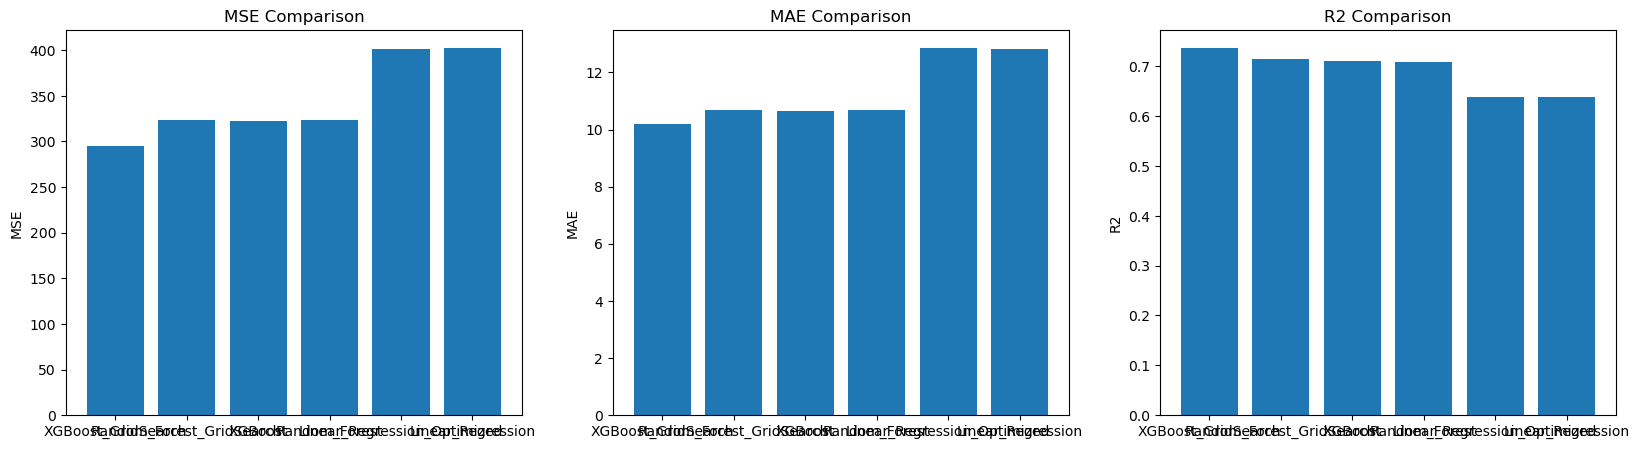

In [90]:
compare_models_metrics()

In [91]:
# Get the best model's run_id
experiment = mlflow.get_experiment_by_name("Rental_Price_Prediction")
runs = mlflow.search_runs(experiment_ids=experiment.experiment_id, order_by=["metrics.mse ASC"])
best_run_id = runs.iloc[0].run_id

# Register the best model with a "Production" alias
model_uri = f"runs:/{best_run_id}/model"
model_version = mlflow.register_model(model_uri, "rental_price_predictor")
client = mlflow.tracking.MlflowClient()

client.set_registered_model_alias(
    name="rental_price_predictor",
    alias="production",
    version=model_version.version
)

Registered model 'rental_price_predictor' already exists. Creating a new version of this model...
2026/04/05 21:33:12 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: rental_price_predictor, version 6
Created version '6' of model 'rental_price_predictor'.


Now our best model is registered in MLflow with a "Production" alias. We can use this model for making predictions in our API by loading it using the alias.

This way, whenever we have a new best model, we can simply update the "Production" alias to point to this new model. Our API will then automatically start using the new best model.

In [92]:
# Get the model with the "production" alias
model_version = client.get_model_version_by_alias(
    name="rental_price_predictor",
    alias="production"
)

# Get the run from this model
run = client.get_run(model_version.run_id)

# Get the best model metrics
rmse = np.sqrt(run.data.metrics['mse'])
mean_price = y_test.mean()

# Calculate the relative error
print(f"Mean price : {mean_price:.2f}€")
print(f"RMSE : {rmse:.2f}€")
print(f"Relative error : {rmse / mean_price * 100:.1f}%")

Mean price : 122.71€
RMSE : 17.14€
Relative error : 14.0%


Now we can export the best model from the local environment to reuse it for the API:

In [93]:
# Load the model from the registry
model = mlflow.sklearn.load_model("models:/rental_price_predictor@production")

# Save it for deployment with joblib
joblib.dump(model, "../MODELS/rental_price_predictor.joblib")

['../MODELS/rental_price_predictor.joblib']

Based on the metrics comparison, the tuned XGBoost model achieves the lowest MSE and MAE, as well as the highest R2 score, making it our best performing model.

## Conclusion

In this chapter, we trained and evaluated different regression models to predict rental prices. We started with a simple Linear Regression as a baseline, then progressively moved to more complex models like Ridge Regression, Random Forest, and XGBoost. 

For each model, we logged the trained model, its parameters, and evaluation metrics in MLflow. This allows us to easily compare models and ensures reproducibility.

We also performed hyperparameter tuning using GridSearchCV for the Ridge and Random Forest models, and a RandomSearchCV for XGBoost model (much more possible combinaisons), which improved their performance over the default versions.

After comparing the models on MSE, RMSE and R2 metrics, the tuned XGBoost model emerged as the best performer with the lowest RMSE (17.14), and the highest R2 score (0.73). This means that for a mean rental price of 122,71€, we have a relative error of 14% representing (17,14€).

We registered this best model in the MLflow Model Registry with a "Production" alias. 

This model will be used in our deployed API using to serve real-time predictions.

By following this structured approach of model training, evaluation, and selection with MLflow tracking, we ensure that we deploy the most accurate model to production in a reproducible and maintainable way.
